# Treinamento e comparação de modelos sobre a ABT

Este notebook compara três classificadores para prever `target` a partir de `DataPipeline/abt.csv`: regressão logística, árvore de decisão e random forest. O pré-processamento é aprendido somente com os dados de treino e fica incorporado ao artefato final.

In [105]:
import importlib.util
import subprocess
import sys
from pathlib import Path
import shap

required_modules = ["matplotlib", "numpy", "pandas", "sklearn"]
missing_modules = [module for module in required_modules if importlib.util.find_spec(module) is None]

print(f"Python/kernel em uso: {sys.executable}")

if missing_modules:
    candidates = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
    requirements_path = next(
        (path / "requirements.txt" for path in candidates if (path / "requirements.txt").is_file()),
        None,
    )
    if requirements_path is None:
        raise FileNotFoundError("requirements.txt não encontrado. Execute o notebook a partir de data-platform ou da raiz do projeto.")

    print(f"Instalando dependências ausentes no kernel atual: {missing_modules}")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-r", str(requirements_path)])
else:
    print("Dependências principais já disponíveis no kernel atual.")

Python/kernel em uso: /opt/homebrew/opt/python@3.11/bin/python3.11
Dependências principais já disponíveis no kernel atual.


In [106]:
import pickle
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    precision_recall_curve,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

RANDOM_STATE = 42
TEST_SIZE = 0.20
#DECISION_THRESHOLD = 0.50
DECISION_THRESHOLDS = [0.30, 0.35, 0.40, 0.50, 0.60, 0.65, 0.70]
CV_FOLDS = 5

## 1. Carregamento da ABT

A busca funciona ao executar o notebook pela pasta `Model`, por `data-platform` ou pela raiz do repositório.

In [107]:
project_root = Path.home() / ""
csv_candidates = [
    # project_root / "data-platform/DataPipeline/abt.csv",
    project_root / "work/abt.csv",
    Path("../DataPipeline/abt.csv"),
    Path("DataPipeline/abt.csv"),
    Path("data-platform/DataPipeline/abt.csv"),
    Path("data-platform/DataPipeline/abt.csv"),
    Path("home/jovyan/work/abt.csv"),
]

ABT_PATH = None
searched = []
for path in csv_candidates:
    try:
        candidate = path if path.is_absolute() else path.absolute()
        searched.append(str(candidate))
        if candidate.is_file():
            ABT_PATH = candidate
            break
    except OSError as error:
        searched.append(f"{path} (indisponível: {error})")

if ABT_PATH is None:
    raise FileNotFoundError("abt.csv não encontrado. Caminhos pesquisados:\n" + "\n".join(searched))

df = pd.read_csv(ABT_PATH, encoding="utf-8")
print(f"Arquivo: {ABT_PATH}")
print(f"ABT carregada: {df.shape[0]:,} linhas e {df.shape[1]} colunas")
display(df.head())

Arquivo: /Users/romuloarrivabene/Desktop/ProjetoFinalIA_Andre/ProjetoFinalPosFIA/data-platform/DataPipeline/../DataPipeline/abt.csv
ABT carregada: 307,511 linhas e 42 colunas


,sk_id_curr,target,ext_source_2,ext_source_mean,ext_source_1,ext_source_3,region_rating_client_w_city,days_last_phone_change,days_id_publish,days_registration,...,prev_refused_rate,has_prev_app,bureau_avg_days_credit,bureau_last_days_credit,bureau_active_rate,bureau_active_count,bureau_closed_rate,bureau_debt_credit_ratio,bureau_overdue_count,has_bureau
0,247309,0,0.253372,0.454169,0.508479,0.600658,2,-1262.0,-4366,-5906.0,...,0.000000,1,-238.000000,-85.0,0.666667,2.0,0.333333,0.916411,0.0,1
1,247310,0,0.693939,0.564336,0.505998,0.434733,2,-427.0,-4260,-4582.0,...,0.111111,1,-324.000000,-324.0,0.500000,1.0,0.500000,0.000000,0.0,1
2,247311,0,0.584425,0.486563,0.692229,0.183035,2,-454.0,-2307,-1460.0,...,0.000000,1,-1350.000000,-329.0,0.600000,3.0,0.400000,0.410078,0.0,1
3,247312,0,0.391186,0.244997,0.308937,0.034868,2,0.0,-33,-9053.0,...,1.000000,1,-983.888889,-121.0,0.666667,6.0,0.333333,0.258119,2.0,1
4,247313,0,0.554638,0.427373,0.505998,0.300108,2,-904.0,-2016,-5588.0,...,0.200000,1,-175.500000,-85.0,1.000000,2.0,0.000000,0.407858,0.0,1


## 2. Preparação das variáveis

O identificador `sk_id_curr` não participa do treinamento. Valores infinitos são tratados como ausentes e imputados dentro do pipeline.

In [108]:
required_columns = {"sk_id_curr", "target"}
missing_columns = required_columns.difference(df.columns)
if missing_columns:
    raise ValueError(f"Colunas obrigatórias ausentes na ABT: {sorted(missing_columns)}")

df_model = df.replace([np.inf, -np.inf], np.nan).copy()
X = df_model.drop(columns=["target", "sk_id_curr"])
y = pd.to_numeric(df_model["target"], errors="raise").astype(int)

empty_columns = X.columns[X.isna().all()].tolist()
X = X.drop(columns=empty_columns)

print(f"Variáveis explicativas: {X.shape[1]}")
print(f"Colunas totalmente vazias removidas: {empty_columns}")
print("Distribuição do target (%):")
display(y.value_counts(normalize=True).mul(100).round(2).sort_index())

Variáveis explicativas: 40
Colunas totalmente vazias removidas: []
Distribuição do target (%):


target
0    91.93
1     8.07
Name: proportion, dtype: float64

## 3. Separação entre treino e teste

A estratificação mantém aproximadamente a mesma proporção de inadimplentes nos dois conjuntos.

In [109]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE,
)

numeric_features = X_train.select_dtypes(include=["number", "bool"]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=["number", "bool"]).columns.tolist()
print(f"Treino: {len(X_train):,} | Teste: {len(X_test):,}")
print(f"Numéricas: {len(numeric_features)} | Categóricas: {len(categorical_features)}")

Treino: 246,008 | Teste: 61,503
Numéricas: 35 | Categóricas: 5


## 4. Pré-processamento e comparação de modelos

Medianas, escalas e categorias são aprendidas somente dentro de cada partição de treino da validação cruzada. A comparação usa o mesmo split, o mesmo pré-processamento e as mesmas métricas para os três modelos. A métrica principal de seleção é ROC AUC, pois a base é desbalanceada e o objetivo é ordenar clientes por risco.

In [ ]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=20)),
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features),
])

cv = StratifiedKFold(
    n_splits=CV_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

candidate_models = {
    "logistic_regression": LogisticRegression(
        class_weight="balanced",
        max_iter=100,
        solver="newton-cholesky",
        random_state=RANDOM_STATE,
    ),
    "decision_tree": DecisionTreeClassifier(
        max_depth=6,
        min_samples_leaf=100,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
    "random_forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=8,
        min_samples_leaf=100,
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
}

results = []
fitted_models = {}

for model_name, classifier in candidate_models.items():
    estimator = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", classifier),
    ])
    started_at = time.perf_counter()
    cv_scores = cross_val_score(estimator, X_train, y_train, scoring="roc_auc", cv=cv, n_jobs=-1)
    estimator.fit(X_train, y_train)
    fit_seconds = time.perf_counter() - started_at

    y_probability_model = estimator.predict_proba(X_test)[:, 1]
    y_prediction_model = (y_probability_model >= DECISION_THRESHOLD).astype(int)

    results.append({
        "model": model_name,
        "roc_auc": roc_auc_score(y_test, y_probability_model),
        "accuracy": accuracy_score(y_test, y_prediction_model),
        "precision": precision_score(y_test, y_prediction_model, zero_division=0),
        "average_precision": average_precision_score(y_test, y_probability_model),
        "cv_roc_auc_mean": cv_scores.mean(),
        "cv_roc_auc_std": cv_scores.std(),
        "fit_seconds": round(fit_seconds, 2),
    })
    fitted_models[model_name] = estimator

comparison = pd.DataFrame(results).sort_values(["roc_auc", "precision", "accuracy"], ascending=False)
best_model_name = comparison.iloc[0]["model"]
model = fitted_models[best_model_name]

print(f"Melhor modelo pela ROC AUC: {best_model_name}")
display(comparison.round(4))

## 5. Avaliação do melhor modelo

ROC AUC mede a capacidade geral de ordenação. Accuracy e precision entram na comparação, mas ROC AUC é priorizada porque a base é desbalanceada.

Modelo selecionado: logistic_regression
ROC AUC: 0.7560 | Accuracy: 0.6906 | Precision: 0.1644 | Average Precision: 0.2374

Relatório de classificação (limiar = 0.50):
              precision    recall  f1-score   support

           0     0.9625    0.6904    0.8040     56538
           1     0.1644    0.6939    0.2659      4965

    accuracy                         0.6906     61503
   macro avg     0.5635    0.6921    0.5349     61503
weighted avg     0.8981    0.6906    0.7606     61503



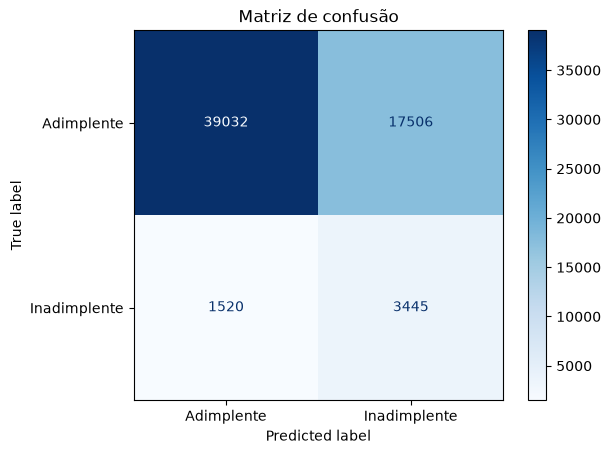

In [ ]:
y_probability = model.predict_proba(X_test)[:, 1]
y_prediction = (y_probability >= DECISION_THRESHOLD).astype(int)

roc_auc = roc_auc_score(y_test, y_probability)
accuracy = accuracy_score(y_test, y_prediction)
precision_model = precision_score(y_test, y_prediction, zero_division=0)
average_precision = average_precision_score(y_test, y_probability)

print(f"Modelo selecionado: {best_model_name}")
print(f"ROC AUC: {roc_auc:.4f} | Accuracy: {accuracy:.4f} | Precision: {precision_model:.4f} | Average Precision: {average_precision:.4f}")
print(f"\nRelatório de classificação (limiar = {DECISION_THRESHOLD:.2f}):")
print(classification_report(y_test, y_prediction, digits=4))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_prediction,
    display_labels=["Adimplente", "Inadimplente"],
    cmap="Blues",
)
plt.title("Matriz de confusão")
plt.show()

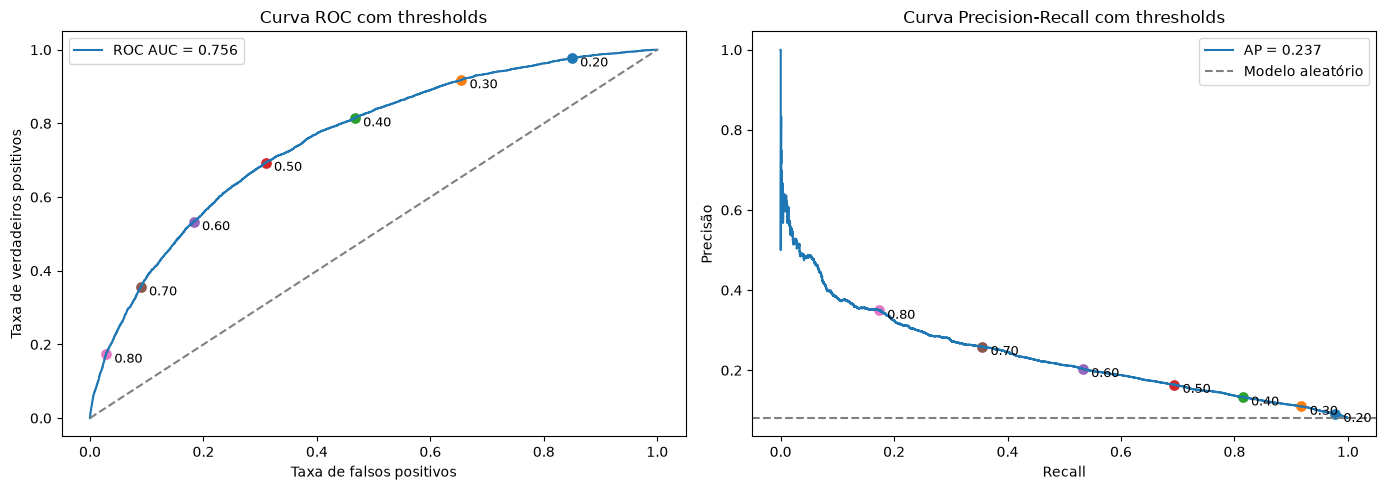

In [ ]:
from sklearn.metrics import roc_curve, precision_recall_curve

fpr, tpr, roc_thresholds = roc_curve(y_test, y_probability)
precision, recall, pr_thresholds = precision_recall_curve(y_test, y_probability)

threshold_marks = DECISION_THRESHOLDS

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(fpr, tpr, label=f"ROC AUC = {roc_auc:.3f}")
axes[0].plot([0, 1], [0, 1], "--", color="gray")

for threshold in threshold_marks:
    idx = np.argmin(np.abs(roc_thresholds - threshold))
    axes[0].scatter(fpr[idx], tpr[idx], s=45)
    axes[0].annotate(
        f"{threshold:.2f}",
        (fpr[idx], tpr[idx]),
        textcoords="offset points",
        xytext=(6, -6),
        fontsize=9,
    )

axes[0].set(
    title="Curva ROC com thresholds",
    xlabel="Taxa de falsos positivos",
    ylabel="Taxa de verdadeiros positivos",
)
axes[0].legend()

axes[1].plot(recall, precision, label=f"AP = {average_precision:.3f}")
axes[1].axhline(y_test.mean(), linestyle="--", color="gray", label="Modelo aleatório")

for threshold in threshold_marks:
    idx = np.argmin(np.abs(pr_thresholds - threshold))
    axes[1].scatter(recall[idx], precision[idx], s=45)
    axes[1].annotate(
        f"{threshold:.2f}",
        (recall[idx], precision[idx]),
        textcoords="offset points",
        xytext=(6, -6),
        fontsize=9,
    )

axes[1].set(
    title="Curva Precision-Recall com thresholds",
    xlabel="Recall",
    ylabel="Precisão",
)
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score

lucro_por_adimplente = 1000
prejuizo_por_inadimplente = 5000

#thresholds = np.arange(0.10, 0.91, 0.01)
thresholds = DECISION_THRESHOLDS
results = []

for threshold in thresholds:
    y_pred = (y_probability >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    lucro = (
        tn * lucro_por_adimplente
        - fp * lucro_por_adimplente
        - fn * prejuizo_por_inadimplente
        + tp * prejuizo_por_inadimplente
    )

    results.append({
        "threshold": threshold,
        "tn_adimplente_aprovado": tn,
        "fp_adimplente_rejeitado": fp,
        "fn_inadimplente_aprovado": fn,
        "tp_inadimplente_rejeitado": tp,
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred),
        "lucro_estimado": lucro,
    })

df_thresholds = pd.DataFrame(results)

In [ ]:
df_thresholds.sort_values("lucro_estimado", ascending=False).head(20)

,threshold,tn_adimplente_aprovado,fp_adimplente_rejeitado,fn_inadimplente_aprovado,tp_inadimplente_rejeitado,precision,recall,lucro_estimado
6,0.70,51488,5050,3202,1763,0.258770,0.355086,39243000
5,0.65,49073,7465,2760,2205,0.228025,0.444109,38833000
4,0.60,46208,10330,2321,2644,0.203792,0.532528,37493000
3,0.50,39032,17506,1520,3445,0.164431,0.693857,31151000
2,0.40,30151,26387,921,4044,0.132891,0.814502,19379000
1,0.35,24930,31608,653,4312,0.120045,0.868479,11617000
0,0.30,19542,36996,407,4558,0.109689,0.918026,3301000


In [ ]:
threshold_results = []

for threshold in DECISION_THRESHOLDS:
    y_pred_threshold = (y_probability >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_threshold).ravel()

    threshold_results.append({
        "threshold": threshold,
        "accuracy": accuracy_score(y_test, y_pred_threshold),
        "precision": precision_score(y_test, y_pred_threshold, zero_division=0),
        "recall": recall_score(y_test, y_pred_threshold, zero_division=0),
        "f1": f1_score(y_test, y_pred_threshold, zero_division=0),
        "tn_adimplente_aprovado": tn,
        "fp_adimplente_rejeitado": fp,
        "fn_inadimplente_aprovado": fn,
        "tp_inadimplente_rejeitado": tp,
    })

threshold_comparison = pd.DataFrame(threshold_results)
display(threshold_comparison.round(4))

,threshold,accuracy,precision,recall,f1,tn_adimplente_aprovado,fp_adimplente_rejeitado,fn_inadimplente_aprovado,tp_inadimplente_rejeitado
0,0.30,0.3919,0.1097,0.9180,0.1960,19542,36996,407,4558
1,0.35,0.4755,0.1200,0.8685,0.2109,24930,31608,653,4312
2,0.40,0.5560,0.1329,0.8145,0.2285,30151,26387,921,4044
3,0.50,0.6906,0.1644,0.6939,0.2659,39032,17506,1520,3445
4,0.60,0.7943,0.2038,0.5325,0.2948,46208,10330,2321,2644
5,0.65,0.8337,0.2280,0.4441,0.3013,49073,7465,2760,2205
6,0.70,0.8658,0.2588,0.3551,0.2994,51488,5050,3202,1763


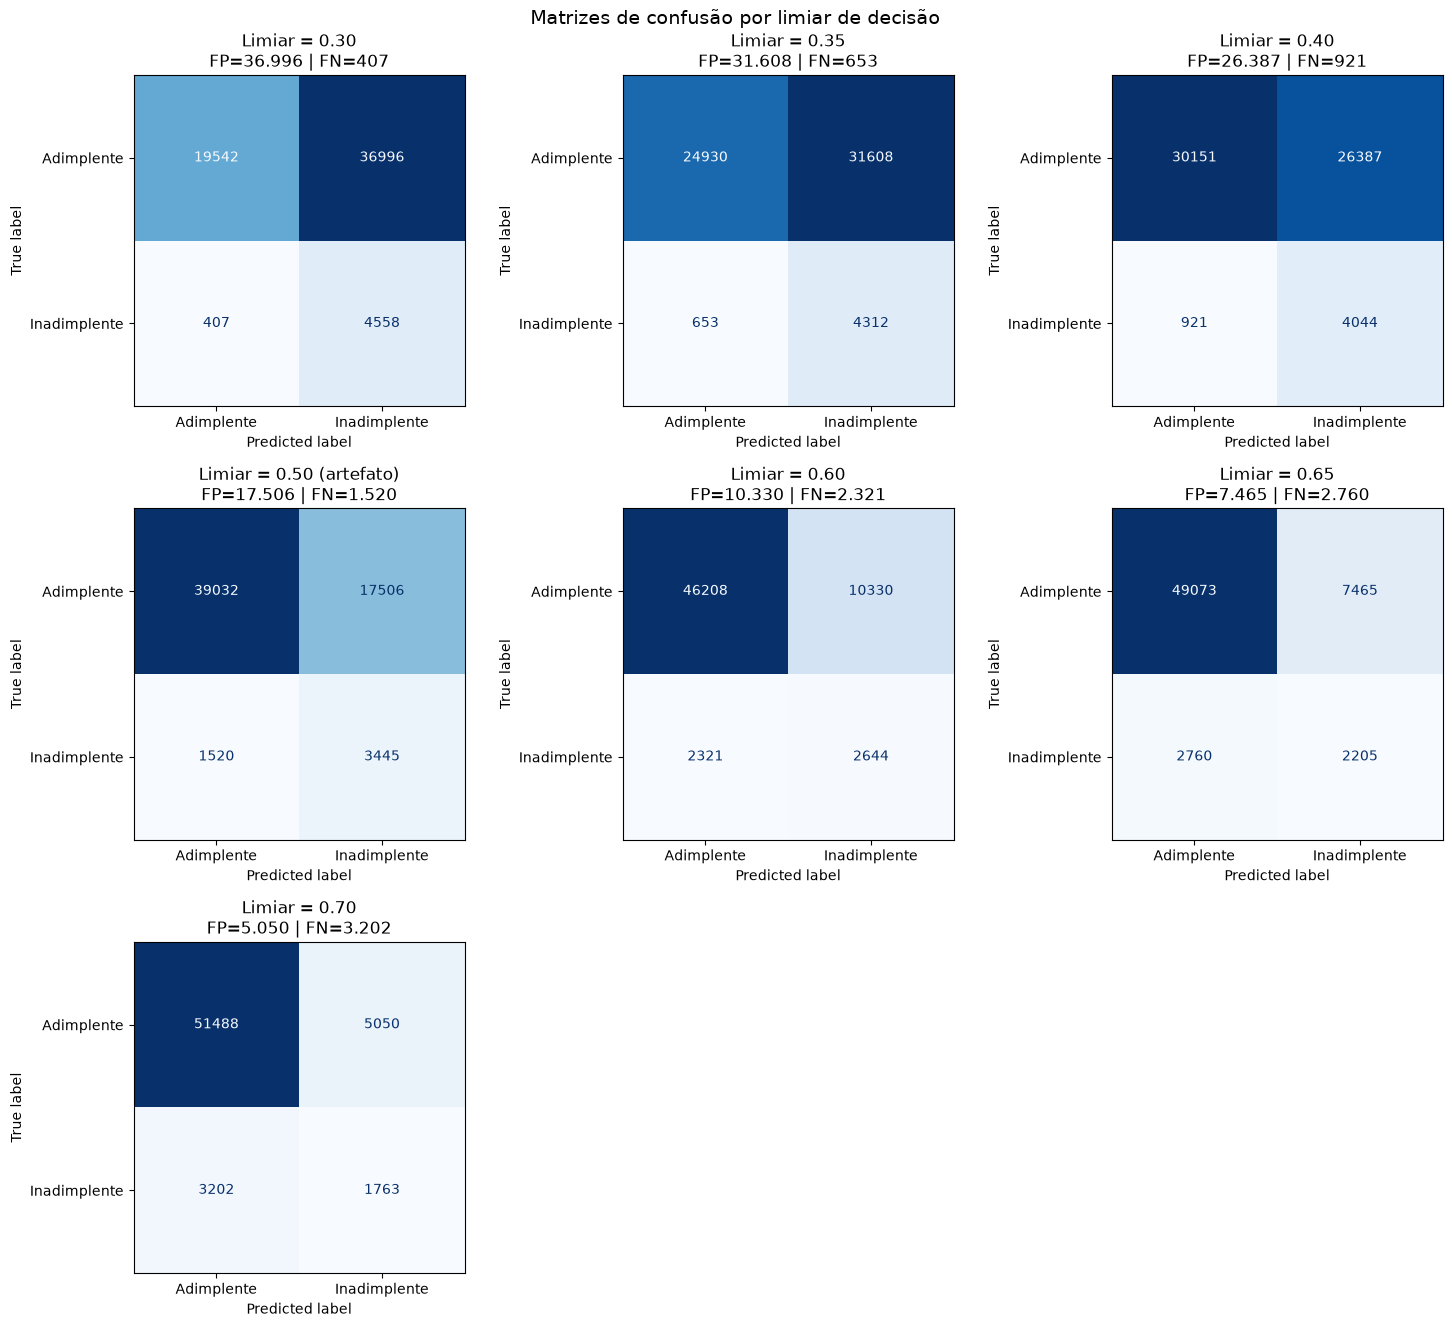

In [ ]:
n_columns = 3
n_rows = int(np.ceil(len(DECISION_THRESHOLDS) / n_columns))
fig, axes = plt.subplots(n_rows, n_columns, figsize=(15, 4.5 * n_rows))
axes = np.atleast_1d(axes).ravel()

for ax, threshold in zip(axes, DECISION_THRESHOLDS):
    y_pred_threshold = (y_probability >= threshold).astype(int)
    cm = confusion_matrix(y_test, y_pred_threshold)
    tn, fp, fn, tp = cm.ravel()

    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Adimplente", "Inadimplente"],
    ).plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)

    selected = " (artefato)" if threshold == DECISION_THRESHOLD else ""
    ax.set_title(
        f"Limiar = {threshold:.2f}{selected}\n"
        f"FP={fp:,} | FN={fn:,}".replace(",", ".")
    )

for ax in axes[len(DECISION_THRESHOLDS):]:
    ax.remove()

fig.suptitle("Matrizes de confusão por limiar de decisão", fontsize=14)
plt.tight_layout()
plt.show()

Em termos de negócio:  
0.30 é muito defensivo: evita muito calote, mas sacrifica vendas demais.  
0.70 preserva vendas, mas deixa passar inadimplente demais.  
0.50 está no meio, mas ainda rejeita 17.136 bons clientes.  
0.60 parece um candidato interessante: reduz bastante os falsos positivos em relação ao 0.50, de 17.136 para 10.259, mas perde 742 inadimplentes capturados.  
0.40 é o inverso: captura mais inadimplentes que 0.50, mas rejeita mais 8.699 bons clientes.

Pergunta chave: o lucro de aprovar 6.877 clientes bons a mais compensa o prejuízo de deixar passar 742 inadimplentes a mais?  
Podemos escolher 0.60 se: lucro_por_cliente_bom multiplicado por 6.877 > prejuizo_por_inadimplente multiplicado por 742.  
Do contrário podemos escolher 0.50.

## Análise de sensibilidade ao desbalanceamento

Nesta seção, comparamos a regressão logística selecionada com e sem `class_weight="balanced"`, mantendo o mesmo split, o mesmo pré-processamento e a mesma grade de hiperparâmetros. O objetivo é avaliar o efeito do balanceamento sobre ROC AUC, Average Precision, Precision, Recall e matriz de confusão.

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.base import clone
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

balance_experiments = {
    "sem_balanceamento": None,
    "com_balanceamento": "balanced",
}

balance_results = []
balance_models = {}
balance_probabilities = {}

for experiment_name, class_weight in balance_experiments.items():
    estimator = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            solver="newton-cholesky",
            max_iter=100,
            random_state=42,
            class_weight=class_weight,
        )),
    ])

    param_grid_balance = {
        "classifier__C": [0.01, 0.1, 1.0, 10.0, 100.0],
    }

    grid_balance = GridSearchCV(
        estimator=estimator,
        param_grid=param_grid_balance,
        scoring="roc_auc",
        cv=cv,
        n_jobs=-1,
        refit=True,
        return_train_score=True,
    )

    grid_balance.fit(X_train, y_train)

    y_probability_balance = grid_balance.best_estimator_.predict_proba(X_test)[:, 1]
    y_pred_balance = (y_probability_balance >= 0.50).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_balance).ravel()

    balance_results.append({
        "experimento": experiment_name,
        "class_weight": class_weight,
        "best_C": grid_balance.best_params_["classifier__C"],
        "roc_auc": roc_auc_score(y_test, y_probability_balance),
        "average_precision": average_precision_score(y_test, y_probability_balance),
        "precision": precision_score(y_test, y_pred_balance, zero_division=0),
        "recall": recall_score(y_test, y_pred_balance),
        "f1": f1_score(y_test, y_pred_balance),
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
    })

    balance_models[experiment_name] = grid_balance.best_estimator_
    balance_probabilities[experiment_name] = y_probability_balance

df_balance_results = pd.DataFrame(balance_results)
df_balance_results

,experimento,class_weight,best_C,roc_auc,average_precision,precision,recall,f1,tn,fp,fn,tp
0,sem_balanceamento,None,0.10,0.755689,0.238791,0.582677,0.014904,0.029065,56485,53,4891,74
1,com_balanceamento,balanced,0.01,0.756115,0.237337,0.164152,0.692447,0.265390,39032,17506,1527,3438


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def plot_confusion_by_thresholds(y_test, y_probability, model_name, thresholds):
    fig, axes = plt.subplots(1, len(thresholds), figsize=(5 * len(thresholds), 4))

    if len(thresholds) == 1:
        axes = [axes]

    for ax, threshold in zip(axes, thresholds):
        y_pred = (y_probability >= threshold).astype(int)
        cm = confusion_matrix(y_test, y_pred)

        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=["Adimplente", "Inadimplente"]
        )

        disp.plot(
            ax=ax,
            cmap="Blues",
            values_format="d",
            colorbar=False
        )

        tn, fp, fn, tp = cm.ravel()

        ax.set_title(
            f"{model_name}\n"
            f"Threshold = {threshold:.2f}\n"
            f"FP={fp:,} | FN={fn:,}".replace(",", ".")
        )

    plt.tight_layout()
    plt.show()

A comparação mostra que o balanceamento por class_weight altera significativamente a distribuição das probabilidades e, consequentemente, o efeito do threshold de classificação.  
Sem balanceamento, thresholds convencionais como 0.50 quase não identificam inadimplentes, exigindo cortes muito menores para obter recall relevante. Com balanceamento, thresholds entre 0.40 e 0.60 já produzem maior captura da classe inadimplente. 
Como a ROC AUC dos dois modelos é praticamente igual, a decisão final deve ser baseada na política de risco desejada e no impacto econômico dos falsos positivos e falsos negativos.

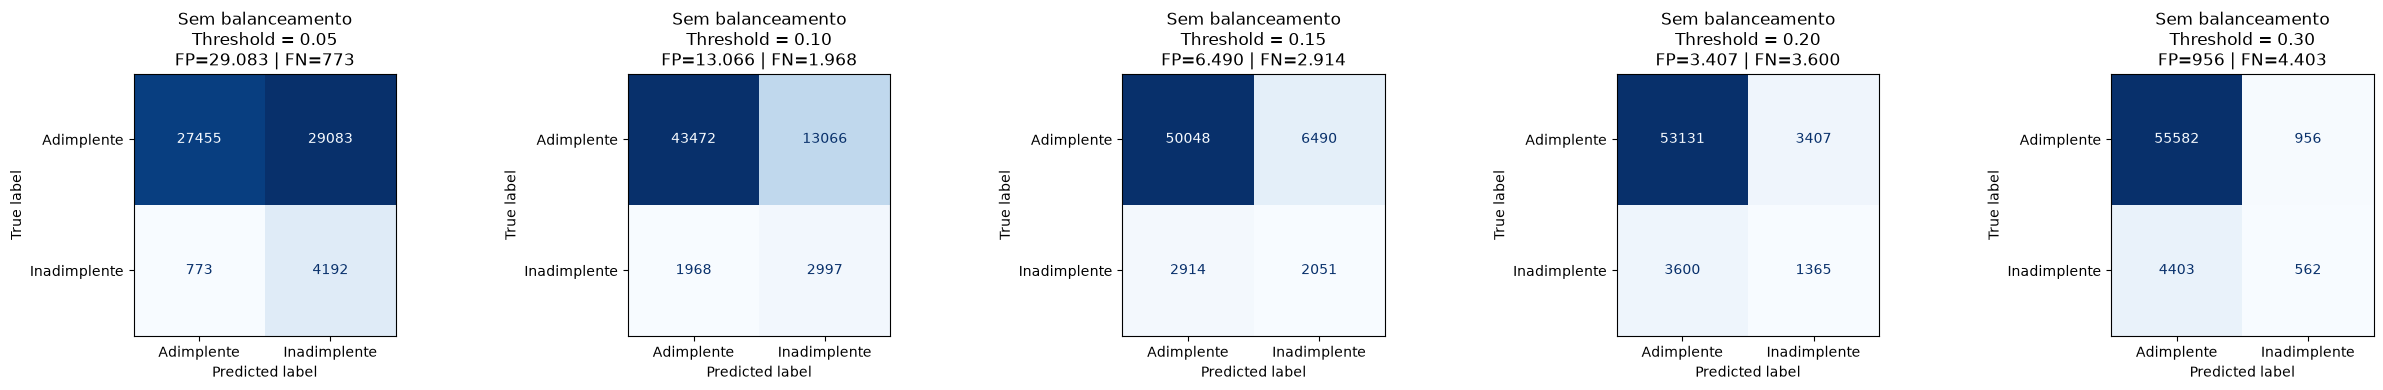

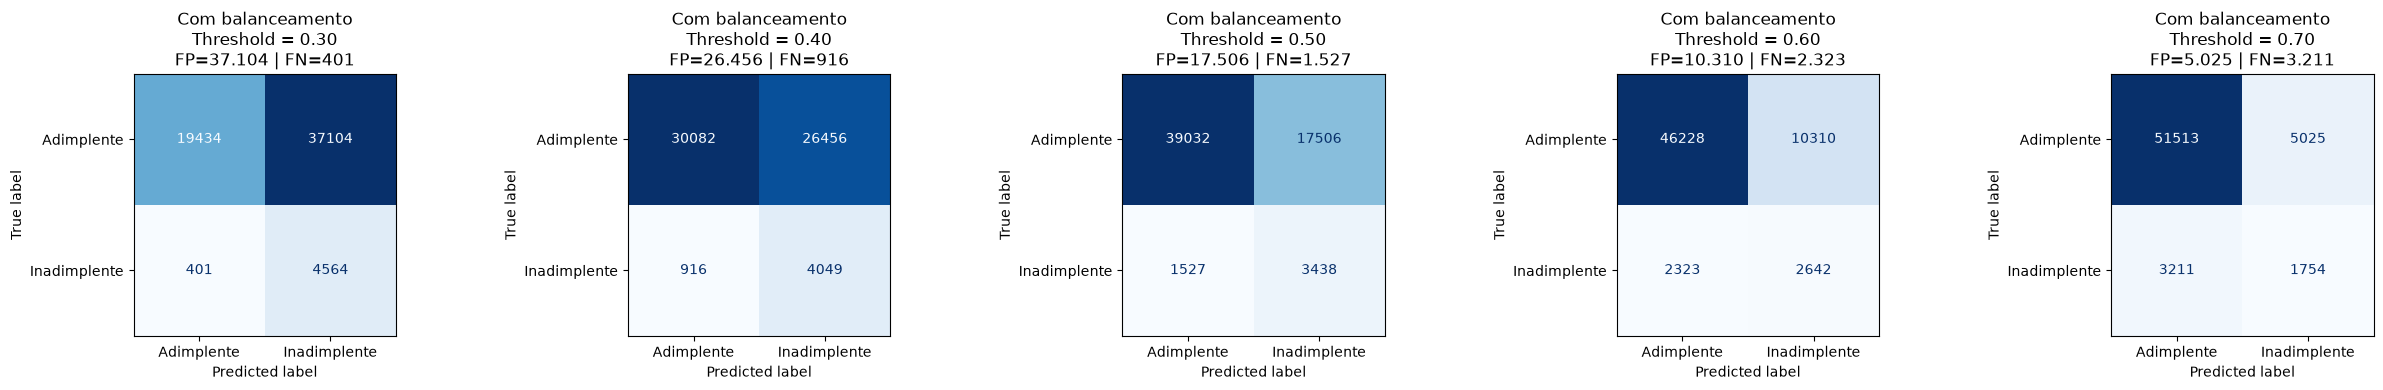

In [ ]:
thresholds_sem_balanceamento = [0.05, 0.10, 0.15, 0.20, 0.30]

plot_confusion_by_thresholds(
    y_test,
    balance_probabilities["sem_balanceamento"],
    "Sem balanceamento",
    thresholds_sem_balanceamento
)

thresholds_com_balanceamento = [0.30, 0.40, 0.50, 0.60, 0.70]
plot_confusion_by_thresholds(
    y_test,
    balance_probabilities["com_balanceamento"],
    "Com balanceamento",
    thresholds_com_balanceamento
)

# Testes usando undersampling class_weight=None equivalente a class_weight="balanced"

In [ ]:
%pip install imbalanced-learn
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler

Note: you may need to restart the kernel to use updated packages.


In [ ]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler

from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)

undersampling_pipeline = ImbPipeline([
    ("undersampler", RandomUnderSampler(random_state=42)),
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        solver="newton-cholesky",
        max_iter=100,
        random_state=42,
        class_weight=None,
    )),
])

param_grid_undersampling = {
    "classifier__C": [0.01, 0.1, 1.0, 10.0, 100.0],
}

grid_undersampling = GridSearchCV(
    estimator=undersampling_pipeline,
    param_grid=param_grid_undersampling,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    refit=True,
    return_train_score=True,
)

grid_undersampling.fit(X_train, y_train)

y_probability_undersampling = grid_undersampling.best_estimator_.predict_proba(X_test)[:, 1]
y_pred_undersampling = (y_probability_undersampling >= 0.50).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_undersampling).ravel()

undersampling_result = {
    "experimento": "undersampling",
    "class_weight": None,
    "best_C": grid_undersampling.best_params_["classifier__C"],
    "roc_auc": roc_auc_score(y_test, y_probability_undersampling),
    "average_precision": average_precision_score(y_test, y_probability_undersampling),
    "precision": precision_score(y_test, y_pred_undersampling, zero_division=0),
    "recall": recall_score(y_test, y_pred_undersampling),
    "f1": f1_score(y_test, y_pred_undersampling),
    "tn": tn,
    "fp": fp,
    "fn": fn,
    "tp": tp,
}

pd.DataFrame([undersampling_result])

,experimento,class_weight,best_C,roc_auc,average_precision,precision,recall,f1,tn,fp,fn,tp
0,undersampling,None,0.1,0.756143,0.23675,0.163891,0.691843,0.265005,39014,17524,1530,3435


In [ ]:
df_balance_results = pd.concat([
    df_balance_results,
    pd.DataFrame([undersampling_result])
], ignore_index=True)

df_balance_results

,experimento,class_weight,best_C,roc_auc,average_precision,precision,recall,f1,tn,fp,fn,tp
0,sem_balanceamento,None,0.10,0.755689,0.238791,0.582677,0.014904,0.029065,56485,53,4891,74
1,com_balanceamento,balanced,0.01,0.756115,0.237337,0.164152,0.692447,0.265390,39032,17506,1527,3438
2,undersampling,None,0.10,0.756143,0.236750,0.163891,0.691843,0.265005,39014,17524,1530,3435


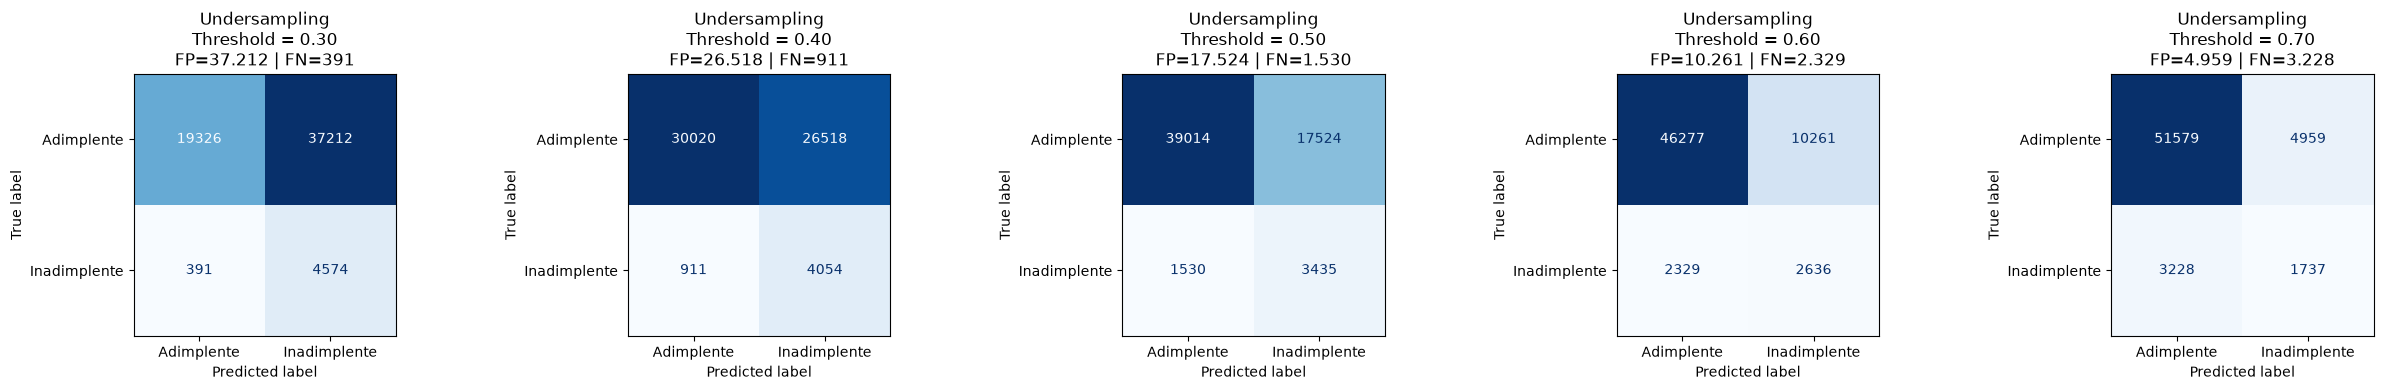

In [ ]:
plot_confusion_by_thresholds(
    y_test,
    y_probability_undersampling,
    "Undersampling",
    [0.30, 0.40, 0.50, 0.60, 0.70]
)

# Testes usando diferentes taxas de undersampling e class_weight="balanced"

In [ ]:
# ============================================================
# Treina um modelo por sampling_strategy e avalia thresholds
# ============================================================

sampling_strategies = [0.10, 0.15, 0.20, 0.30, 0.50, 0.75, 1.0]
thresholds = [0.30, 0.40, 0.50, 0.60, 0.70]

undersampling_models_by_rate = {}
undersampling_probabilities_by_rate = {}
undersampling_results_by_rate = []

for sampling_strategy in sampling_strategies:
    pipeline = ImbPipeline([
        ("undersampler", RandomUnderSampler(
            sampling_strategy=sampling_strategy,
            random_state=42,
        )),
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            solver="newton-cholesky",
            max_iter=100,
            random_state=42,
            class_weight=None,
        )),
    ])

    grid = GridSearchCV(
        estimator=pipeline,
        param_grid={"classifier__C": [0.01, 0.1, 1.0, 10.0, 100.0]},
        scoring="roc_auc",
        cv=cv,
        n_jobs=-1,
        refit=True,
        return_train_score=True,
    )

    grid.fit(X_train, y_train)

    y_probability_rate = grid.best_estimator_.predict_proba(X_test)[:, 1]

    undersampling_models_by_rate[sampling_strategy] = grid.best_estimator_
    undersampling_probabilities_by_rate[sampling_strategy] = y_probability_rate

    for threshold in thresholds:
        y_pred_rate = (y_probability_rate >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred_rate).ravel()

        undersampling_results_by_rate.append({
            "sampling_strategy": sampling_strategy,
            "best_C": grid.best_params_["classifier__C"],
            "cv_roc_auc_mean": grid.best_score_,
            "threshold": threshold,
            "roc_auc": roc_auc_score(y_test, y_probability_rate),
            "average_precision": average_precision_score(y_test, y_probability_rate),
            "precision": precision_score(y_test, y_pred_rate, zero_division=0),
            "recall": recall_score(y_test, y_pred_rate),
            "f1": f1_score(y_test, y_pred_rate),
            "tn": tn,
            "fp": fp,
            "fn": fn,
            "tp": tp,
        })

df_undersampling_by_rate = pd.DataFrame(undersampling_results_by_rate)
df_undersampling_by_rate.sort_values(["sampling_strategy", "threshold"])

,sampling_strategy,best_C,cv_roc_auc_mean,threshold,roc_auc,average_precision,precision,recall,f1,tn,fp,fn,tp
0,0.10,0.1,0.746459,0.3,0.755773,0.238636,0.359113,0.146828,0.208435,55237,1301,4236,729
1,0.10,0.1,0.746459,0.4,0.755773,0.238636,0.464234,0.064048,0.112566,56171,367,4647,318
2,0.10,0.1,0.746459,0.5,0.755773,0.238636,0.540541,0.020141,0.038835,56453,85,4865,100
3,0.10,0.1,0.746459,0.6,0.755773,0.238636,0.651163,0.005639,0.011182,56523,15,4937,28
4,0.10,0.1,0.746459,0.7,0.755773,0.238636,0.750000,0.000604,0.001207,56537,1,4962,3
5,0.15,0.1,0.746430,0.3,0.755778,0.238552,0.288071,0.274320,0.281028,53172,3366,3603,1362
6,0.15,0.1,0.746430,0.4,0.755778,0.238552,0.364850,0.137563,0.199795,55349,1189,4282,683
7,0.15,0.1,0.746430,0.5,0.755778,0.238552,0.461207,0.064653,0.113408,56163,375,4644,321
8,0.15,0.1,0.746430,0.6,0.755778,0.238552,0.550802,0.020745,0.039984,56454,84,4862,103
9,0.15,0.1,0.746430,0.7,0.755778,0.238552,0.657143,0.004632,0.009200,56526,12,4942,23


## 6. Variáveis mais influentes 

## 6.1. Usando classifier.feature_importances

Quando o melhor modelo é linear, os coeficientes indicam associação com a pontuação de inadimplência. Quando é baseado em árvore, usamos a importância das variáveis do próprio modelo. Em ambos os casos, interpretabilidade não significa causalidade.

In [ ]:
feature_names = model.named_steps["preprocessor"].get_feature_names_out()
classifier = model.named_steps["classifier"]

if hasattr(classifier, "coef_"):
    importance = pd.DataFrame({
        "feature": feature_names,
        "importance": classifier.coef_[0],
        "absolute_importance": np.abs(classifier.coef_[0]),
    }).sort_values("absolute_importance", ascending=False)
elif hasattr(classifier, "feature_importances_"):
    importance = pd.DataFrame({
        "feature": feature_names,
        "importance": classifier.feature_importances_,
        "absolute_importance": classifier.feature_importances_,
    }).sort_values("absolute_importance", ascending=False)
else:
    importance = pd.DataFrame(columns=["feature", "importance", "absolute_importance"])

In [ ]:
display(importance.head(50))

,feature,importance,absolute_importance
101,categorical__name_education_type_Academic degree,-1.274420,1.274420
98,categorical__name_income_type_Pensioner,-0.969472,0.969472
92,categorical__organization_type_Transport: type 3,0.540920,0.540920
104,categorical__name_education_type_Lower secondary,0.539574,0.539574
87,categorical__organization_type_Trade: type 2,-0.501682,0.501682
108,categorical__code_gender_infrequent_sklearn,-0.474014,0.474014
105,categorical__name_education_type_Secondary / s...,0.411189,0.411189
75,categorical__organization_type_Military,-0.407520,0.407520
107,categorical__code_gender_M,0.403430,0.403430
55,categorical__organization_type_Bank,-0.364627,0.364627


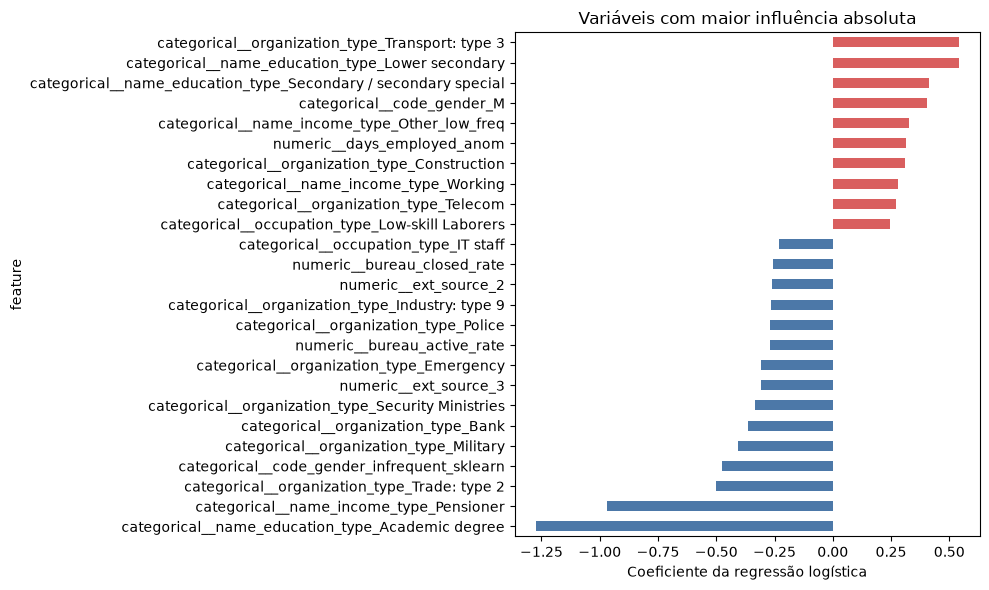

In [ ]:
top = importance.head(25).sort_values('importance')
colors = np.where(top['importance'] >= 0, '#d95f5f', '#4c78a8')
top.plot.barh(x='feature', y='importance', color=colors, legend=False, figsize=(10, 6))
plt.title('Variáveis com maior influência absoluta')
plt.xlabel('Coeficiente da regressão logística')
plt.tight_layout(); plt.show()

In [ ]:
df_model.columns

Index(['sk_id_curr', 'target', 'ext_source_2', 'ext_source_mean',
       'ext_source_1', 'ext_source_3', 'region_rating_client_w_city',
       'days_last_phone_change', 'days_id_publish', 'days_registration',
       'reg_city_not_work_city', 'reg_city_not_live_city',
       'live_city_not_work_city', 'has_car', 'own_car_age',
       'def_60_cnt_social_circle', 'amt_req_credit_bureau_year',
       'cnt_children', 'cnt_fam_members', 'amt_income_total', 'amt_credit',
       'amt_annuity', 'occupation_type', 'organization_type',
       'name_income_type', 'name_education_type', 'code_gender', 'age',
       'years_employed', 'days_employed_anom', 'fe_credit_income_percent',
       'fe_annuity_income_percent', 'prev_refused_rate', 'has_prev_app',
       'bureau_avg_days_credit', 'bureau_last_days_credit',
       'bureau_active_rate', 'bureau_active_count', 'bureau_closed_rate',
       'bureau_debt_credit_ratio', 'bureau_overdue_count', 'has_bureau'],
      dtype='object')

In [ ]:
print(df_model["days_employed_anom"].head())
print(df_model.info())

0    0
1    1
2    0
3    0
4    0
Name: days_employed_anom, dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 42 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   sk_id_curr                   307511 non-null  int64  
 1   target                       307511 non-null  int64  
 2   ext_source_2                 307511 non-null  float64
 3   ext_source_mean              307511 non-null  float64
 4   ext_source_1                 307511 non-null  float64
 5   ext_source_3                 307511 non-null  float64
 6   region_rating_client_w_city  307511 non-null  int64  
 7   days_last_phone_change       307511 non-null  float64
 8   days_id_publish              307511 non-null  int64  
 9   days_registration            307511 non-null  float64
 10  reg_city_not_work_city       307511 non-null  int64  
 11  reg_city_not_live_city       307511 non-nul

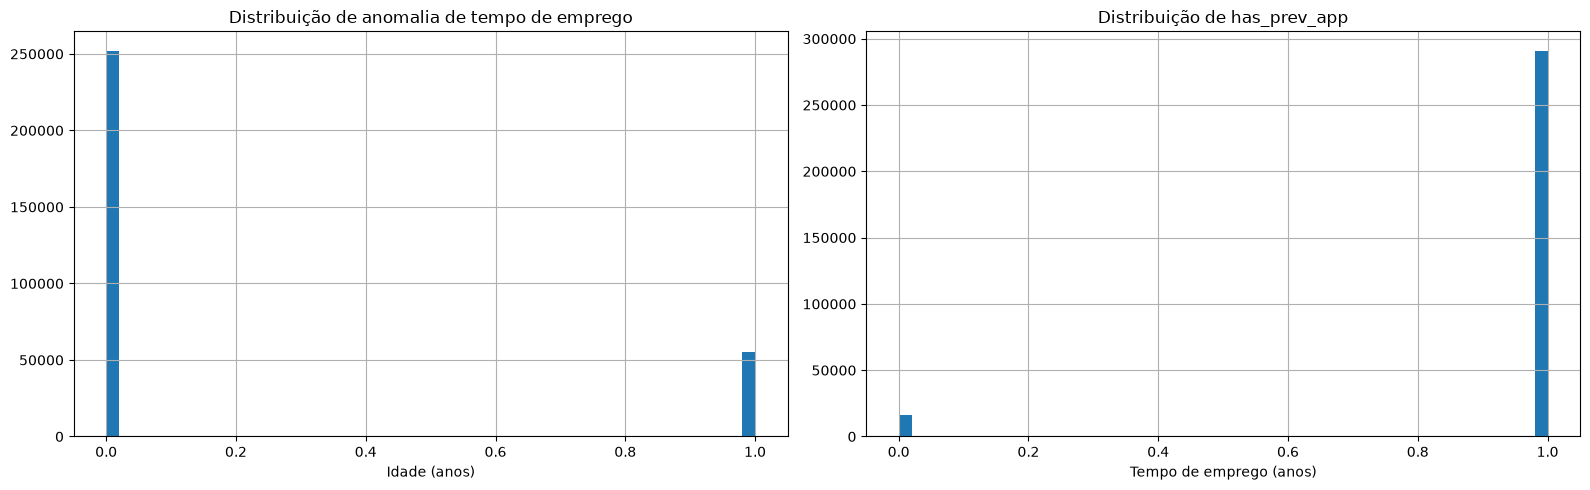

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
df_model["days_employed_anom"].hist(bins=50, ax=axes[0]); axes[0].set_title("Distribuição de anomalia de tempo de emprego"); axes[0].set_xlabel("Idade (anos)")
# df_model["years_employed"].hist(bins=50, ax=axes[1]); axes[1].set_title("Distribuição de tempo de emprego"); axes[1].set_xlabel("Tempo de emprego (anos)")
df_model["has_prev_app"].hist(bins=50, ax=axes[1]); axes[1].set_title("Distribuição de has_prev_app"); axes[1].set_xlabel("Tempo de emprego (anos)")
plt.tight_layout(); plt.show()

## 6.2  Usando SHAP

In [ ]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Modelo final selecionado no notebook
model_for_shap = model

# Valida estrutura esperada do pipeline
required_steps = {"preprocessor", "classifier"}
available_steps = set(model_for_shap.named_steps.keys())

missing_steps = required_steps - available_steps
if missing_steps:
    raise ValueError(f"Pipeline sem steps esperados: {missing_steps}")

preprocessor_for_shap = model_for_shap.named_steps["preprocessor"]
classifier_for_shap = model_for_shap.named_steps["classifier"]

if not hasattr(classifier_for_shap, "coef_"):
    raise TypeError(
        "Este código usa shap.LinearExplainer e espera um modelo linear com coef_. "
        f"Modelo encontrado: {type(classifier_for_shap)}"
    )

# Amostra para acelerar o cálculo e visualização
shap_sample_size = min(3000, len(X_test))
X_shap = X_test.sample(shap_sample_size, random_state=42).copy()

# Aplica o mesmo pré-processamento usado pelo modelo
X_shap_transformed = preprocessor_for_shap.transform(X_shap)

# Recupera nomes das features após ColumnTransformer / OneHotEncoder
feature_names = preprocessor_for_shap.get_feature_names_out()

# SHAP trabalha melhor com matriz densa neste caso
if hasattr(X_shap_transformed, "toarray"):
    X_shap_transformed = X_shap_transformed.toarray()

X_shap_transformed_df = pd.DataFrame(
    X_shap_transformed,
    columns=feature_names,
    index=X_shap.index,
)

# Explicador SHAP para regressão logística / modelo linear
explainer = shap.LinearExplainer(
    classifier_for_shap,
    X_shap_transformed_df,
)

shap_values = explainer(X_shap_transformed_df)

print(f"Amostra usada no SHAP: {len(X_shap_transformed_df):,} linhas")
print(f"Features após pré-processamento: {X_shap_transformed_df.shape[1]:,}")

Amostra usada no SHAP: 3,000 linhas
Features após pré-processamento: 109


,feature,mean_abs_shap,mean_shap
98,categorical__name_income_type_Pensioner,0.277851,-0.006463
3,numeric__ext_source_3,0.234447,0.004255
22,numeric__days_employed_anom,0.233618,0.005434
29,numeric__bureau_active_rate,0.230804,0.025772
31,numeric__bureau_closed_rate,0.226163,-0.018188
0,numeric__ext_source_2,0.212822,0.041280
107,categorical__code_gender_M,0.184529,0.003227
11,numeric__has_car,0.165275,-0.023285
105,categorical__name_education_type_Secondary / s...,0.163585,-0.018778
1,numeric__ext_source_mean,0.158589,0.023333


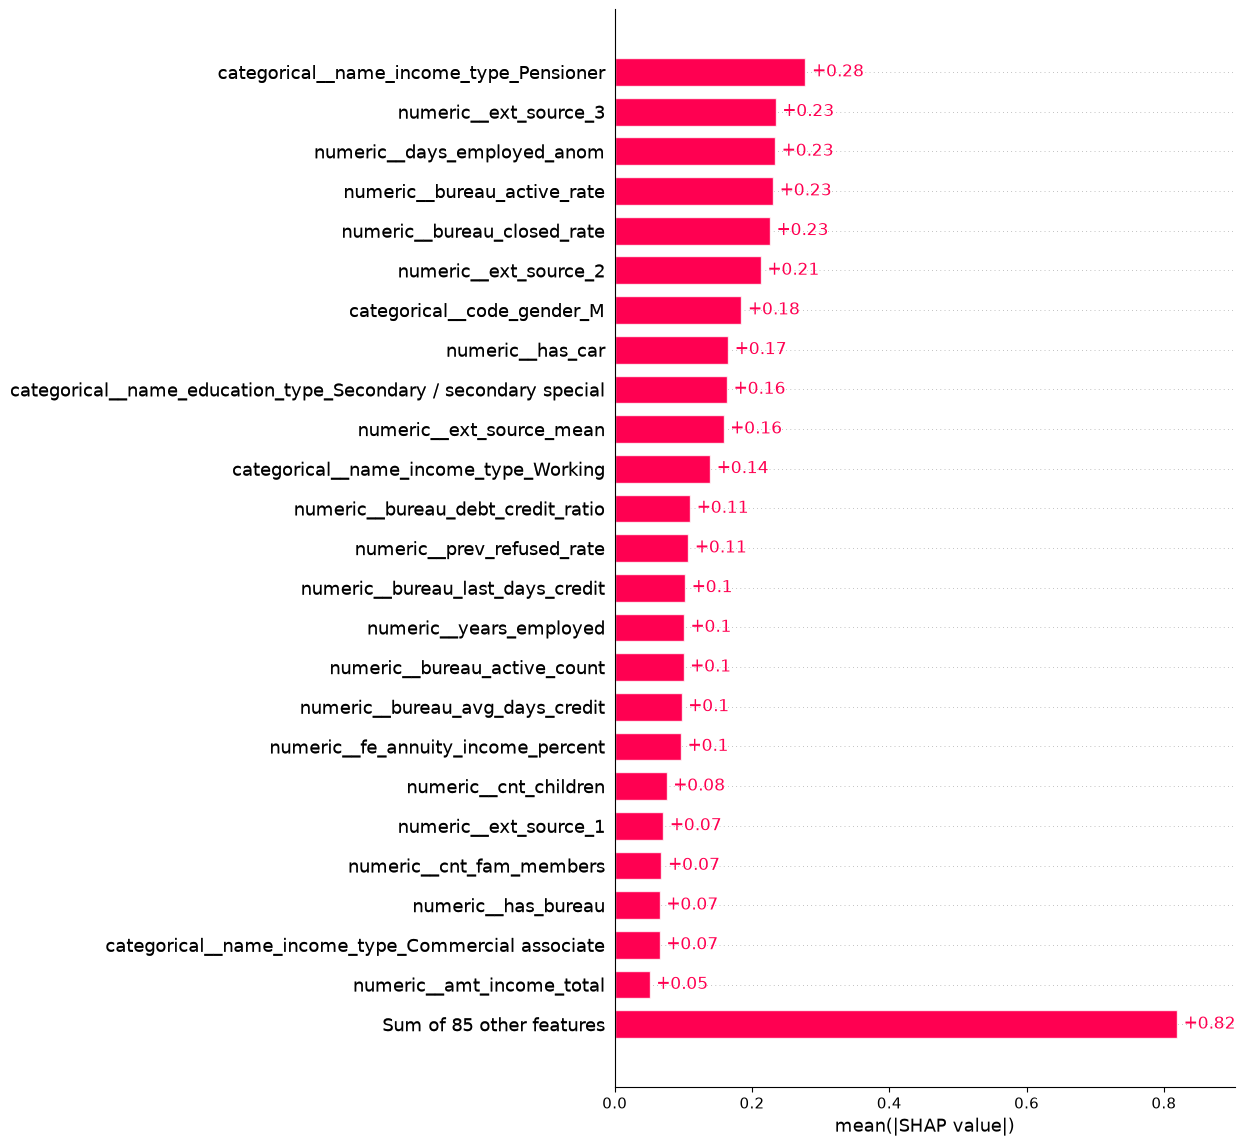

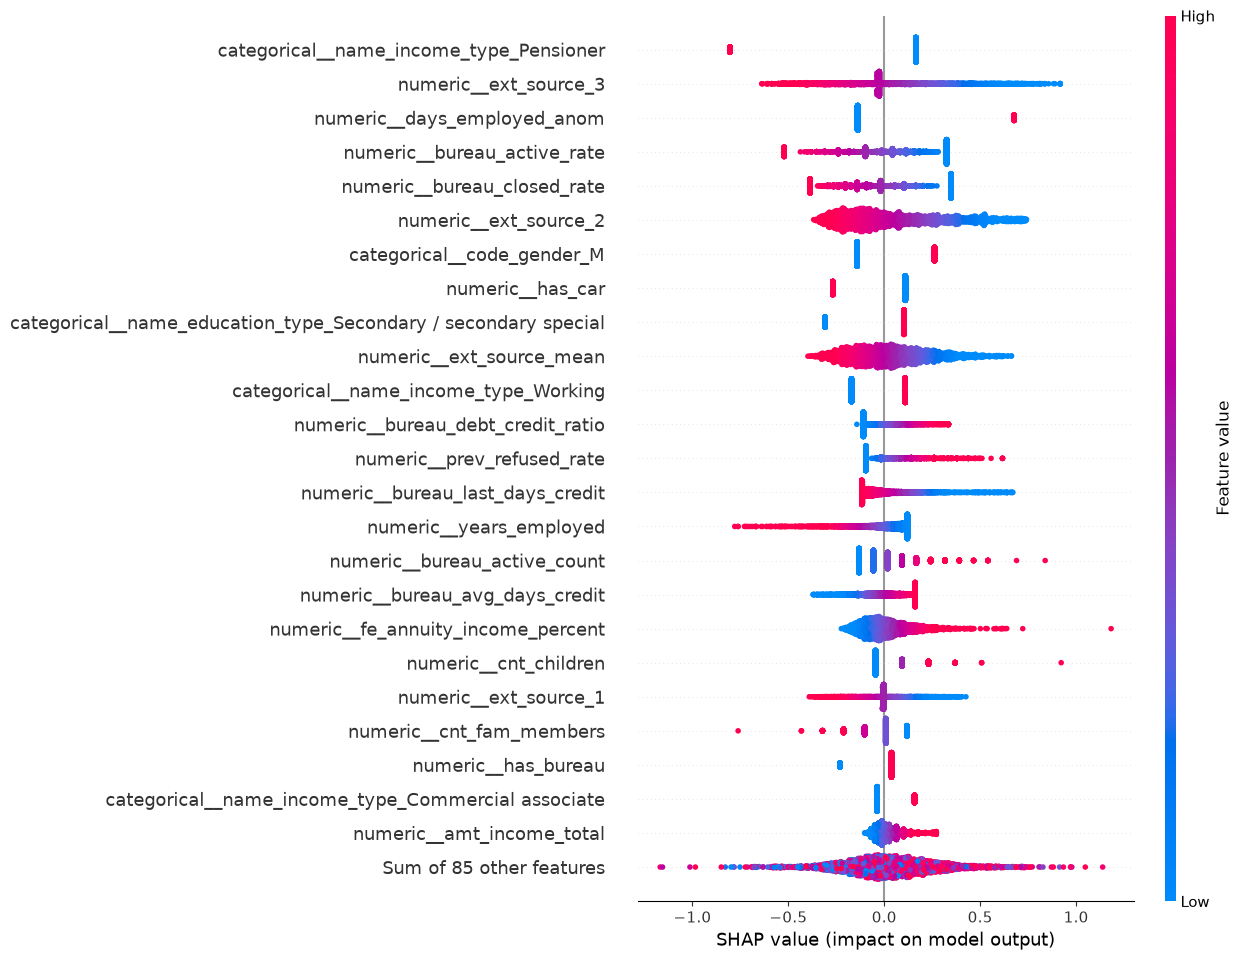

In [ ]:
df_shap_importance = pd.DataFrame({
    "feature": X_shap_transformed_df.columns,
    "mean_abs_shap": np.abs(shap_values.values).mean(axis=0),
    "mean_shap": shap_values.values.mean(axis=0),
}).sort_values("mean_abs_shap", ascending=False)

display(df_shap_importance.head(30))

shap.plots.bar(shap_values, max_display=25)
shap.plots.beeswarm(shap_values, max_display=25)

Leitura objetiva do gráfico SHAP:
Valores SHAP positivos empurram o modelo para inadimplente.
Valores SHAP negativos empurram para adimplente.
A cor indica valor da feature: vermelho = alto, azul = baixo.

Principais sinais:  
days_employed_anom  
É a variável mais forte. Quando a flag está alta (1), tende bastante para inadimplente. Isso confirma que a anomalia em days_employed carrega sinal de risco.

name_income_type_Pensioner  
Tende fortemente para adimplente. Ser pensionista reduz o risco estimado.

name_income_type_Working e Commercial associate  
Tende para inadimplente. O modelo associa essas categorias a maior risco comparado às categorias de referência.

ext_source_2, ext_source_3, ext_source_mean  
Valores baixos tendem para inadimplente; valores altos empurram para adimplente. Isso é coerente: maior score externo reduz risco.

bureau_active_rate, bureau_closed_rate, bureau_debt_credit_ratio, prev_refused_rate  
Indicadores de histórico de crédito parecem relevantes. Em geral, maior endividamento/recusa anterior tende para risco.

has_car: ter carro parece reduzir risco enquanto não ter aumenta o risco.

# Conclusão: 
A análise SHAP confirma que o modelo combina sinais socioeconômicos, histórico de crédito e scores externos. As variáveis EXT_SOURCE reduzem o risco quando apresentam valores altos, enquanto indicadores de histórico negativo, como taxa de pagamentos atrasados, recusas anteriores e maior razão dívida/crédito, aumentam a propensão estimada à inadimplência.  
Categorias associadas a maior estabilidade de renda, como Pensioner, reduzem o risco, enquanto Working e Commercial associate aumentam o risco relativo.  
A variável days_employed_anom aparece como o principal fator global, indicando forte associação entre a anomalia no tempo de emprego e a classe inadimplente, que está associada a quem não tem um emprego formal.

## 7. Persistência do modelo

O artefato contém pré-processamento, classificador, limiar e metadados necessários para inferência.

In [ ]:
ARTIFACT_DIR = ABT_PATH.parent.parent / "Model/artifacts"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_PATH = ARTIFACT_DIR / "logistic_regression_abt.pkl"
COMPARISON_PATH = ARTIFACT_DIR / "model_comparison.csv"

artifact = {
    "model": model,
    "model_name": best_model_name,
    "decision_threshold": DECISION_THRESHOLD,
    "input_features": X.columns.tolist(),
    "metrics": {
        "roc_auc": roc_auc,
        "accuracy": accuracy,
        "precision": precision_model,
        "average_precision": average_precision,
        "cv_roc_auc": comparison.iloc[0]["cv_roc_auc_mean"],
    },
    "model_comparison": comparison.to_dict(orient="records"),
    "cv_folds": CV_FOLDS,
}
with MODEL_PATH.open("wb") as file:
    pickle.dump(artifact, file)
comparison.to_csv(COMPARISON_PATH, index=False)
print(f"Modelo salvo em: {MODEL_PATH.resolve()}")

Modelo salvo em: /Users/romuloarrivabene/Desktop/ProjetoFinalIA_Andre/ProjetoFinalPosFIA/data-platform/Model/artifacts/logistic_regression_abt.pkl
